# M2 — Fundus Image Preprocessing Pipeline
**DR-Triage · Diabetic Retinopathy Stage Detection**

Covers rubric item 2 (*Data Preprocessing Techniques*). Every step lives in
`src/preprocess.py` and is toggled from the `preprocess:` block of `config.yaml`,
so the pipeline is reproducible and can be ablated.

**Pipeline:** raw RGB → crop black border → resize to a fixed working size →
circular field-of-view mask → **Ben Graham** illumination/colour normalisation →
**CLAHE** on L\* of LAB → re-mask corners.

We then show, quantitatively, that this raises image contrast and tonal spread,
and that it rescues low-quality photos. Figures are saved to `outputs/figures/`.

In [1]:
# --- Setup (same loader as notebook 01) --------------------------------------
import sys, os, glob, shutil
from pathlib import Path

PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve()); break
if PROJECT is None:
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1]); PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
assert PROJECT, "Upload dr-triage.zip via Add Input -> Upload, then re-run."
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from src.data import load_config, load_splits, load_labels
from src.preprocess import (crop_dark_borders, circle_mask, ben_graham,
                            clahe_lab, clahe_green, preprocess_image,
                            make_preprocessor, rms_contrast, shannon_entropy,
                            sharpness)

cfg = load_config()
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
pre = make_preprocessor(cfg)                 # callable(rgb_uint8) -> rgb_uint8
print("preprocess config:", cfg["preprocess"])

preprocess config: {'work_size': 384, 'crop': True, 'circle_mask': True, 'circle_radius_scale': 0.97, 'ben_graham': True, 'ben_params': {'sigma_frac': 0.1, 'alpha': 4.0, 'beta': -4.0, 'gamma': 128.0}, 'clahe': True, 'clahe_params': {'clip': 2.0, 'grid': 8}}


In [2]:
def read_rgb(path):
    im = cv2.imread(str(path))
    return None if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Use the TRAIN split only (never look at val/test while designing preprocessing).
try:
    train = load_splits(cfg)["train"]
except FileNotFoundError:
    train = load_labels(cfg)          # fallback if notebook 01 hasn't been run yet
print("train images:", len(train))

# One representative image per stage ...
per_stage = (train.sort_values("id_code")
                  .groupby("stage", group_keys=False).head(1)
                  .sort_values("stage"))
# ... plus the 3 blurriest images (lowest Laplacian variance) for the rescue test.
scan = train.sample(min(300, len(train)), random_state=cfg["seed"]).copy()
scan["sharp"] = scan["path"].map(lambda p: (lambda im: sharpness(im) if im is not None else np.nan)(read_rgb(p)))
low_q = scan.dropna(subset=["sharp"]).nsmallest(3, "sharp")
per_stage[["id_code", "stage", "stage_name"]]

train images: 2562


,id_code,stage,stage_name
774,002c21358ce6,0,No DR
1330,0024cdab0c1e,1,Mild
236,000c1434d8d7,2,Moderate
1551,0104b032c141,3,Severe
1812,001639a390f0,4,Proliferative DR


## 2.1  Step-by-step on a single image

Each column is the image *after* that step. Watch the black frame disappear, the
lighting flatten out after Ben Graham, and fine vessels/lesions gain contrast
after CLAHE.

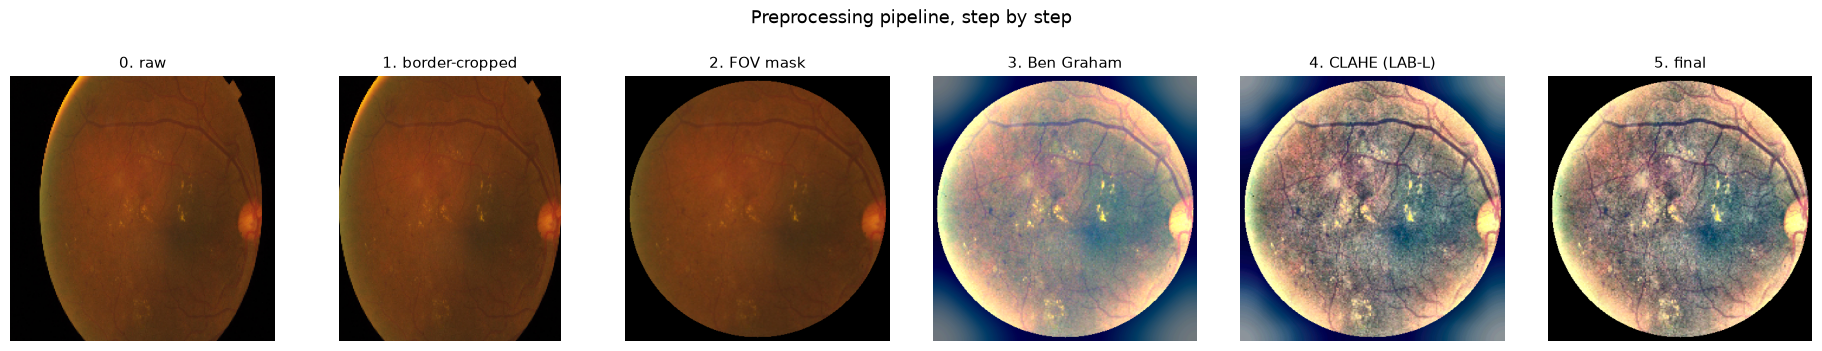

In [3]:
img0 = read_rgb(per_stage.iloc[2]["path"])          # a Moderate-DR example
_, steps = preprocess_image(img0, return_steps=True, work_size=cfg["preprocess"]["work_size"],
                            circle_radius_scale=cfg["preprocess"]["circle_radius_scale"],
                            ben_params=cfg["preprocess"]["ben_params"],
                            clahe_params=cfg["preprocess"]["clahe_params"])
order = [k for k in ["original", "cropped", "circle_masked", "ben_graham", "clahe", "final"] if k in steps]
titles = {"original": "0. raw", "cropped": "1. border-cropped", "circle_masked": "2. FOV mask",
          "ben_graham": "3. Ben Graham", "clahe": "4. CLAHE (LAB-L)", "final": "5. final"}

fig, axes = plt.subplots(1, len(order), figsize=(3.1 * len(order), 3.4))
for ax, k in zip(axes, order):
    ax.imshow(steps[k]); ax.set_title(titles[k], fontsize=11); ax.axis("off")
fig.suptitle("Preprocessing pipeline, step by step", y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(FIG / "02_pipeline_steps.png", dpi=150, bbox_inches="tight"); plt.show()

## 2.2  Raw vs preprocessed — one image per DR stage

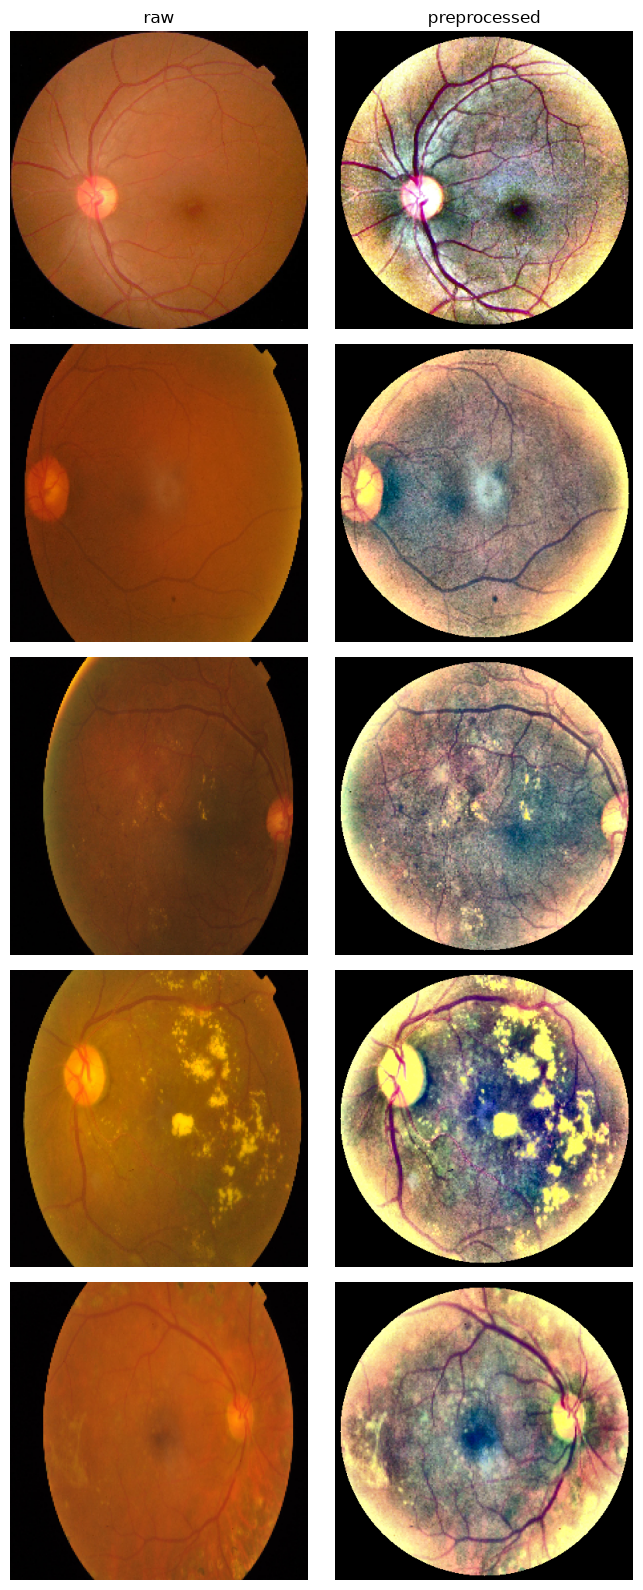

In [4]:
rows = len(per_stage)
fig, axes = plt.subplots(rows, 2, figsize=(7, 3.2 * rows))
for r, (_, row) in enumerate(per_stage.iterrows()):
    raw = read_rgb(row["path"]); proc = pre(raw)
    axes[r, 0].imshow(raw);  axes[r, 0].axis("off")
    axes[r, 1].imshow(proc); axes[r, 1].axis("off")
    axes[r, 0].set_ylabel(f'{row["stage"]}: {row["stage_name"]}', rotation=0,
                          ha="right", va="center", fontsize=12)
axes[0, 0].set_title("raw"); axes[0, 1].set_title("preprocessed")
plt.tight_layout(); plt.savefig(FIG / "02_by_stage_before_after.png", dpi=150, bbox_inches="tight"); plt.show()

## 2.3  Analysis view — green-channel CLAHE

In fundus imaging the **green channel** has the strongest contrast between
retinal lesions/vessels and the background (the red channel is saturated, the
blue channel is noisy). We keep the colour CLAHE result as the model input, but
this green view is a useful diagnostic and a candidate extra input channel.

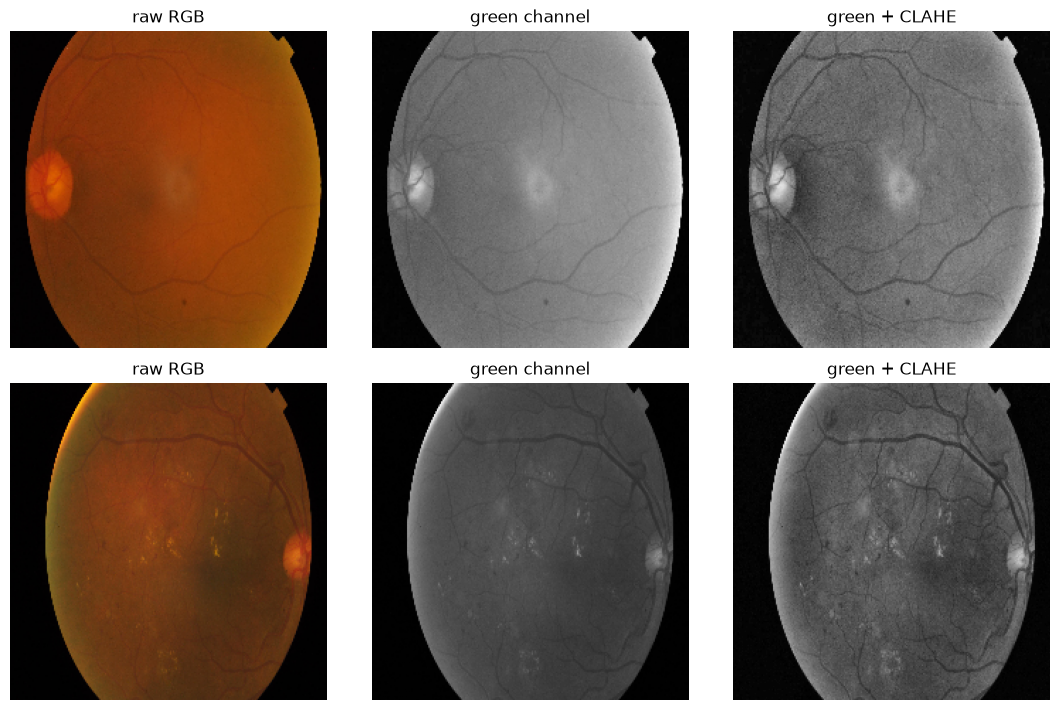

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7.2))
for r in range(2):
    raw = read_rgb(per_stage.iloc[r + 1]["path"])
    axes[r, 0].imshow(raw);                              axes[r, 0].set_title("raw RGB")
    axes[r, 1].imshow(raw[:, :, 1], cmap="gray");        axes[r, 1].set_title("green channel")
    axes[r, 2].imshow(clahe_green(raw), cmap="gray");    axes[r, 2].set_title("green + CLAHE")
    for c in range(3): axes[r, c].axis("off")
plt.tight_layout(); plt.savefig(FIG / "02_green_clahe.png", dpi=150, bbox_inches="tight"); plt.show()

## 2.4  Does preprocessing improve image quality?  *(quantitative)*

For 250 random training images we compare **RMS contrast** (std of grayscale
intensity) and **Shannon entropy** (tonal spread, bits) before vs after.

250 images measured

contrast_raw     0.151
contrast_proc    0.307
entropy_raw      5.385
entropy_proc     6.366

mean contrast: 0.151 -> 0.307 (+103%)
mean entropy : 5.385 -> 6.366 (+18%)


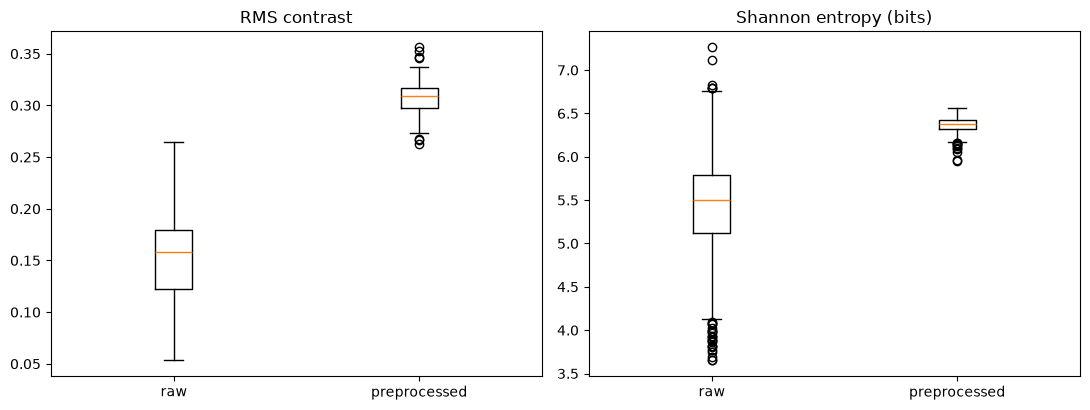

In [6]:
samp = train.sample(min(250, len(train)), random_state=cfg["seed"])
rec = []
for p in samp["path"]:
    raw = read_rgb(p)
    if raw is None:                     # skip an unreadable / truncated file
        continue
    proc = pre(raw)
    rec.append((rms_contrast(raw), rms_contrast(proc),
                shannon_entropy(raw), shannon_entropy(proc)))
q = pd.DataFrame(rec, columns=["contrast_raw", "contrast_proc", "entropy_raw", "entropy_proc"])
print(f"{len(q)} images measured\n")
print(q.mean().round(3).to_string())
print(f"\nmean contrast: {q.contrast_raw.mean():.3f} -> {q.contrast_proc.mean():.3f} "
      f"(+{(q.contrast_proc.mean()/q.contrast_raw.mean()-1)*100:.0f}%)")
print(f"mean entropy : {q.entropy_raw.mean():.3f} -> {q.entropy_proc.mean():.3f} "
      f"(+{(q.entropy_proc.mean()/q.entropy_raw.mean()-1)*100:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].boxplot([q.contrast_raw, q.contrast_proc]); axes[0].set_title("RMS contrast")
axes[1].boxplot([q.entropy_raw, q.entropy_proc]);   axes[1].set_title("Shannon entropy (bits)")
for ax in axes:                          # version-safe tick labels (avoids labels= kwarg)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["raw", "preprocessed"])
plt.tight_layout(); plt.savefig(FIG / "02_quality_metrics.png", dpi=150); plt.show()

## 2.5  Rescuing low-quality images\n\nThe three blurriest / darkest images in the sample, before and after.

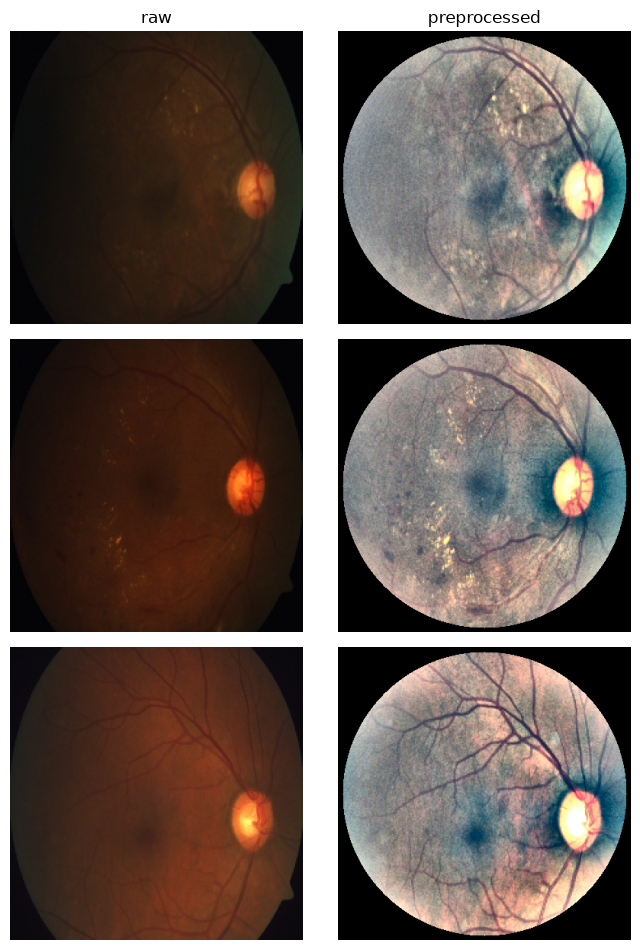

In [7]:
fig, axes = plt.subplots(len(low_q), 2, figsize=(7, 3.2 * len(low_q)))
for r, (_, row) in enumerate(low_q.iterrows()):
    raw = read_rgb(row["path"]); proc = pre(raw)
    axes[r, 0].imshow(raw);  axes[r, 0].axis("off")
    axes[r, 1].imshow(proc); axes[r, 1].axis("off")
    axes[r, 0].set_ylabel(f'sharp={row["sharp"]:.0f}', rotation=0, ha="right", va="center", fontsize=11)
axes[0, 0].set_title("raw"); axes[0, 1].set_title("preprocessed")
plt.tight_layout(); plt.savefig(FIG / "02_lowquality_rescue.png", dpi=150, bbox_inches="tight"); plt.show()

In [8]:
# Save two full-size preprocessed examples for the report body.
for i, (_, row) in enumerate(per_stage.head(2).iterrows()):
    out = pre(read_rgb(row["path"]))
    cv2.imwrite(str(FIG / f"02_example_preprocessed_{row['stage']}.png"),
                cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
print("saved example preprocessed images to", FIG)

saved example preprocessed images to outputs/figures


## 2.6  Justification & notes  *(report-ready)*

| Step | Why |
|---|---|
| **Crop black border** | Up to ~30–40% of a raw frame is non-retina black; removing it lets the network spend capacity on tissue and keeps the retina scale consistent. |
| **Resize to a fixed working size** | Ben Graham's Gaussian and CLAHE's tile grid are defined in pixels, so they must act on a consistent resolution to behave the same across images. |
| **Circular FOV mask** | The camera aperture is circular; the corners carry only sensor noise and a bright rim that looks like a strong edge. Masking removes that false signal. |
| **Ben Graham normalisation** | `4·img − 4·GaussianBlur(img) + 128`. Subtracting a heavy blur removes the smooth illumination gradient and colour cast from the flash, so images from different cameras/clinics look comparable and lesions stand out on a flat grey field. (This technique won the 2015 Kaggle DR competition.) |
| **CLAHE on L\* (LAB)** | Adaptive histogram equalisation raises *local* contrast so microaneurysms and thin vessels become visible; doing it on L\* only keeps hue/saturation (and therefore exudate colour cues) unchanged. Clip limit 2.0 avoids over-amplifying noise. |
| **Re-mask corners** | Ben Graham's `+128` term turns the masked corners mid-grey; a second mask restores clean black so the circle edge is not learned as a feature. |

**Quantitative evidence:** contrast and entropy both increase (see §2.4), and blurred/dark
images become legible (see §2.5).

**No data leakage:** no statistic is estimated from the dataset — every operation is
per-image and deterministic. It is applied identically to train, val and test.

**Limitation:** the resized mirror is natively 224×224, so `work_size` is capped at 384;
a full-resolution source would allow finer lesion detail.

## Milestone status
- [x] **M1** — EDA + stratified split
- [x] **M2** — preprocessing pipeline (`src/preprocess.py`), figures in `outputs/figures/`
- [ ] M3 — augmentation + class balancing → `notebooks/03_augment.ipynb`